# Dubins car latent preference-aligned safety filter from VLM labels

**What this does:** The full pipeline with VLM labels: world-model latents -> VLM pairwise preference labels -> Bradley-Terry failure margin -> latent safety filter. The VLM replaces the ground-truth labels.

**What it shows:** VLM labels are usable but not perfect. Labeling accuracy ~0.75 and the learned margin achieved ~0.80 held-out accuracy. With ~1000 clean labels held-out accuracy reaches ~0.99, and adding VLM labels on top of clean labels doesn't help.

**Souce code**: `dubins/`.

# VLM Failure Margin

Use a VLM to label preference pairs of Dubins states, learn a Bradley-Terry failure margin in the frozen world model's latent space, and evaluate with label accuracy
and held-out margin accuracy.

Run from the repo root with the `reach_pref` kernel. Labels are generated inline and stored at `dubins/labels/`.

**Workflow**
1. Pretrained world model: 544-d latent state
2. VLM labeling: VLM sees pairs of images and decides which one is better
3. BT margin: trained on the latent state pairs and VLM labels
4. Evaluation: label accuracy + held-out margin accuracy

## Setup

In [1]:
import sys; sys.path.insert(0, "dubins")   # supporting code (generate_*) lives here
import os, sys, re, pickle, argparse
os.environ.setdefault("CUDA_VISIBLE_DEVICES","1"); os.environ.setdefault("HF_HUB_OFFLINE","1")
sys.path.insert(0, os.getcwd()); sys.path.insert(0, "dubins/dreamerv3")
import numpy as np, torch, torch.nn as nn, gym
from torch.nn.utils import spectral_norm
import ruamel.yaml as yaml, tools, models
import matplotlib.pyplot as plt
from PIL import Image
import generate_data_dubins_sidewalk as gen
from generate_pref_labels_dubins_sidewalk import weighted_margin_np, PREF_PROFILES
RUN_VLM=False                       # True re-labels 5000 pairs with Qwen3-VL (GPU, ~30-60 min)
V="dubins/labels"; dev=torch.device("cuda")
import os as _os; _os.makedirs(V, exist_ok=True)

D=pickle.load(open("data/pref_labels_set_a_50k.pkl","rb"))
imgs=D["imgs"]; margin=D["margin"].astype(np.float32); priv=D["priv"]; Mn=len(margin)
R,SW=float(D["R"]),float(D["SW"]); W=PREF_PROFILES["set_a"]
cfg=yaml.YAML(typ="safe",pure=True).load(open("dubins/configs.yaml").read())["defaults"]
config=argparse.Namespace(**{k:tools.args_type(v)(v) for k,v in cfg.items()})
config.num_actions=3; config.device=dev; config.use_margin_head=False

def is_obs(k): return np.hypot(priv[k,0],priv[k,1])<R
def is_sw(k):  return abs(priv[k,1])>SW and not is_obs(k)
def region(k):
    if is_obs(k): return "OBSTACLE"
    if priv[k,1]>SW:  return "UPPER_SIDEWALK"
    if priv[k,1]<-SW: return "LOWER_SIDEWALK"
    return "UPPER_SAFE" if priv[k,1]>=0 else "LOWER_SAFE"
# fixed split: labels come from the train pool, evaluation from the held-out val pool
rng=np.random.default_rng(0); vmask=np.zeros(Mn,bool); vmask[rng.choice(Mn,int(0.2*Mn),replace=False)]=True
train_idx=np.where(~vmask)[0]; val_idx=np.where(vmask)[0]
print(f"{Mn} states | R={R} SW={SW} | train {len(train_idx)} / val {len(val_idx)}")

4000 states | R=0.5 SW=1.1 | train 3200 / val 800


## World model

Loads frozen transition-only world model

In [2]:
sz=config.size[0]
obs_space=gym.spaces.Dict({"obs_state":gym.spaces.Box(-1,1,(2,),np.float32),
                           "image":gym.spaces.Box(0,255,(sz,sz,3),np.uint8)})
wm=models.WorldModel(obs_space,gym.spaces.Discrete(3),0,config).to(dev)
_ck=torch.load("checkpoints/dubins/wm_transition_only.pt",map_location=dev)
_sd={k[len("_wm._orig_mod."):] if k.startswith("_wm._orig_mod.") else k[4:] if k.startswith("_wm.") else k:v
     for k,v in _ck["agent_state_dict"].items() if "_wm" in k}
wm.load_state_dict(_sd,strict=True); wm.eval(); wm.dynamics.sample=False

@torch.no_grad()
def encode(im_arr, ob_arr, chunk=256):
    out=[]
    for k in range(0,len(im_arr),chunk):
        im=im_arr[k:k+chunk].astype(np.float32); ob=ob_arr[k:k+chunk].astype(np.float32); B=len(im)
        acs=np.zeros((B,1,3),np.float32); acs[:,:,1]=1.0
        d={"image":im[:,None],"obs_state":ob[:,None],"action":acs,
           "is_first":np.ones((B,1),np.float32),"is_terminal":np.zeros((B,1),np.float32)}
        d=wm.preprocess(d); e=wm.encoder(d); post,_=wm.dynamics.observe(e,d["action"],d["is_first"])
        out.append(wm.dynamics.get_feat(post)[:,0])
    return torch.cat(out,0)

_fc=f"{V}/pool_feats.pt"
feats=torch.load(_fc,map_location=dev) if os.path.exists(_fc) else encode(D["imgs"],D["obs_state"])
if not os.path.exists(_fc): torch.save(feats,_fc)
print("latents:",tuple(feats.shape))

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


Optimizer model_opt has 27134213 variables.
latents: (4000, 544)


/home/alina/projects/latent_pref_reachability/dubins/dreamerv3/tools.py:891: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## VLM labeling

The VLM sees images A and B and makes the comparison given a prompt. We prompt it with the preference ranking. The model does: locate A -> classify A -> locate B -> classify B -> compare A and B -> give answer.

In [3]:
SCENE=("You will see two pictures from the same top-down map: State A first, then State B. In each "
 "picture: most of the map is plain WHITE background; a GRAY horizontal band runs along the very TOP "
 "edge; another GRAY band runs along the very BOTTOM edge; a RED circle with a green tree sits in the "
 "middle; and there is one small BLUE CAR. Coordinates: x goes from -1.5 (left) to +1.5 (right), y goes "
 "from -1.5 (bottom) to +1.5 (top). The top gray band is y > 1.1, the bottom gray band is y < -1.1, and "
 "the red circle is everything within distance 0.5 of the centre (0,0).")
RULES=("\n\nRegion rules for a car:\n"
 " - if the car is on the RED circle (within distance 0.5 of the centre) -> OBSTACLE\n"
 " - else if the car is on the TOP gray band (y > 1.1) -> UPPER_SIDEWALK\n"
 " - else if the car is on the BOTTOM gray band (y < -1.1) -> LOWER_SIDEWALK\n"
 " - else if the car is on the white background with y >= 0 -> UPPER_SAFE\n"
 " - else (white background, y < 0) -> LOWER_SAFE\n"
 "The tree may cover the car; if the car is on the red circle it is OBSTACLE.")
RANK=("\n\nPreference ranking, safest first:\n"
 " UPPER_SAFE  >  LOWER_SAFE  >  UPPER_SIDEWALK  =  LOWER_SIDEWALK  >  OBSTACLE")
STEPS=("\n\nNow work through these steps and write each one out:\n"
 "Step 1. Car A: say where the blue car is in State A (what it is sitting on, and roughly its y value).\n"
 "Step 2. Region A: give State A's region using the region rules.\n"
 "Step 3. Car B: say where the blue car is in State B (what it is sitting on, and roughly its y value).\n"
 "Step 4. Region B: give State B's region using the region rules.\n"
 "Step 5. Compare Region A and Region B using the preference ranking, and say which one ranks higher.\n"
 'Finally end with a line exactly "Answer: A" or "Answer: B" naming the safer state.')
print(SCENE+RULES+RANK+STEPS)

You will see two pictures from the same top-down map: State A first, then State B. In each picture: most of the map is plain WHITE background; a GRAY horizontal band runs along the very TOP edge; another GRAY band runs along the very BOTTOM edge; a RED circle with a green tree sits in the middle; and there is one small BLUE CAR. Coordinates: x goes from -1.5 (left) to +1.5 (right), y goes from -1.5 (bottom) to +1.5 (top). The top gray band is y > 1.1, the bottom gray band is y < -1.1, and the red circle is everything within distance 0.5 of the centre (0,0).

Region rules for a car:
 - if the car is on the RED circle (within distance 0.5 of the centre) -> OBSTACLE
 - else if the car is on the TOP gray band (y > 1.1) -> UPPER_SIDEWALK
 - else if the car is on the BOTTOM gray band (y < -1.1) -> LOWER_SIDEWALK
 - else if the car is on the white background with y >= 0 -> UPPER_SAFE
 - else (white background, y < 0) -> LOWER_SAFE
The tree may cover the car; if the car is on the red circle it

In [4]:
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
_M="Qwen/Qwen3-VL-4B-Instruct"; DPI=256
proc=AutoProcessor.from_pretrained(_M)
vlm=Qwen3VLForConditionalGeneration.from_pretrained(_M,dtype=torch.bfloat16).to("cuda").eval()
def render(k): return Image.fromarray(gen.render_state(priv[k].astype(np.float32),1.0,0.05,
                                                       gen.load_tree_emoji(),DPI).astype(np.uint8))
@torch.no_grad()
def ask(content,mx=230):
    m=[{"role":"user","content":content}]
    t=proc.apply_chat_template(m,tokenize=False,add_generation_prompt=True)
    vi,vv=process_vision_info(m); inp=proc(text=[t],images=vi,videos=vv,return_tensors="pt").to("cuda")
    n=int(inp["input_ids"].shape[1]); o=vlm.generate(**inp,max_new_tokens=mx,do_sample=False)
    return proc.tokenizer.decode(o[0][n:],skip_special_tokens=True)
def parse_ab(t):
    m=re.findall(r"[Aa]nswer\s*[:\-]?\s*\(?([AB])\b",t); return m[-1].upper() if m else None
def sit(k):
    if is_obs(k): return f"sitting on the red circle (y about {priv[k,1]:+.1f})"
    if is_sw(k):  return f"sitting on the {'top' if priv[k,1]>0 else 'bottom'} gray band (y about {priv[k,1]:+.1f})"
    return f"on the white background (y about {priv[k,1]:+.1f})"
def worked(a,b):
    ra,rb=region(a),region(b); hi=ra if margin[a]>margin[b] else rb
    return (f"Step 1. Car A is {sit(a)}.\nStep 2. Region A = {ra}.\nStep 3. Car B is {sit(b)}.\n"
            f"Step 4. Region B = {rb}.\nStep 5. Comparing {ra} and {rb} with the ranking, {hi} ranks higher.\n"
            f"Answer: {'A' if margin[a]>margin[b] else 'B'}")
def demo_block(seed=4):
    r=np.random.default_rng(seed)
    safe=[k for k in range(Mn) if not is_obs(k) and not is_sw(k)]
    obs=[k for k in range(Mn) if is_obs(k)]; sw=[k for k in range(Mn) if is_sw(k)]
    up=[k for k in safe if priv[k,1]>=0]; lo=[k for k in safe if priv[k,1]<0]
    dm=[(r.choice(safe),r.choice(obs)),(r.choice(sw),r.choice(safe)),(r.choice(up),r.choice(lo)),(r.choice(obs),r.choice(sw))]
    blk=[{"type":"text","text":SCENE+RULES+RANK+"\n\nHere are solved examples showing the steps:"}]
    for a,b in dm:
        a,b=int(a),int(b)
        blk+=[{"type":"text","text":"Example - State A:"},{"type":"image","image":render(a)},
              {"type":"text","text":"State B:"},{"type":"image","image":render(b)},
              {"type":"text","text":worked(a,b)+"\n"}]
    return blk
BLK=demo_block()
def label_pair(i,j,rng=np.random):
    "VLM sees both images and decides. Returns 1 if state i judged safer."
    flip=rng.rand()<0.5; a,b=(j,i) if flip else (i,j)      # randomise presentation order
    c=BLK+[{"type":"text","text":"Now solve this one. State A:"},{"type":"image","image":render(a)},
           {"type":"text","text":"State B:"},{"type":"image","image":render(b)},{"type":"text","text":STEPS}]
    txt=ask(c); p=parse_ab(txt); pref=(a if p=="A" else b) if p else i
    return int(pref==i), txt

r=np.random.default_rng(0); ok=0; shown=False
for _ in range(6):
    i,j=int(r.choice(train_idx)),int(r.choice(train_idx))
    if i==j or abs(margin[i]-margin[j])<0.10: continue
    lab,txt=label_pair(i,j); gt=int(margin[i]>margin[j]); ok+=(lab==gt)
    if not shown:
        print("--- example VLM output ---\n"+txt.strip()[:600]+"\n---"); shown=True
print("demo pairs matched GT on", ok)

/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 713/713 [00:00<00:00, 14566.61it/s]

--- example VLM output ---
Step 1. Car A: In State A, the blue car is sitting on the bottom gray band (y about -1.1).
Step 2. Region A: Since the car is on the bottom gray band (y < -1.1), Region A = LOWER_SIDEWALK.
Step 3. Car B: In State B, the blue car is sitting on the red circle (y about +0.3), as it is positioned on top of the green tree which is centered in the red circle.
Step 4. Region B: Since the car is on the red circle (within distance 0.5 of the centre), Region B = OBSTACLE.
Step 5. Comparing Region A (LOWER_SIDEWALK) and Region B (OBSTACLE) using the preference ranking: LOWER_SIDEWALK is ranked higher tha
---


demo pairs matched GT on 5


## Bradley-Terry failure margin

Trained so the safer state of each pair scores higher. The BT loss only trains the failure margin to rank states by preferences, so its values identify an ordering, and their signs and the natural zero boundary carry no information.

In [5]:
class MarginHead(nn.Module):
    def __init__(s,f,u=512,l=2):
        super().__init__(); d,m=f,[]
        for _ in range(l): m+=[spectral_norm(nn.Linear(d,u)),nn.SiLU()]; d=u
        s.body=nn.Sequential(*m); s.out=spectral_norm(nn.Linear(d,1))
    def forward(s,x): return s.out(s.body(x)).squeeze(-1)

def bt_loss(pred,target,w):
    lp=torch.log_softmax(pred,1); mu=torch.stack([target,1-target],1)
    return ((w*(-(mu*lp).sum(1))).sum())/(w.sum()+1e-8)

def sample_pairs(pool,n,min_gap,seed):
    r=np.random.default_rng(seed); P=[]
    while len(P)<n:
        i,j=int(r.choice(pool)),int(r.choice(pool))
        if i==j or abs(margin[i]-margin[j])<min_gap: continue
        P.append((i,j))
    return np.array(P)

def train_margin(I,J,Y,Wt,steps=3000,seed=0):
    I=torch.tensor(I,device=dev); J=torch.tensor(J,device=dev)
    Y=torch.tensor(Y,dtype=torch.float32,device=dev); Wt=torch.tensor(Wt,dtype=torch.float32,device=dev)
    torch.manual_seed(seed); m=MarginHead(feats.shape[1],config.units).to(dev)
    opt=torch.optim.Adam(m.parameters(),1e-3); N=len(I); bs=min(512,N)
    for _ in range(steps):
        b=torch.randint(N,(bs,),device=dev)
        loss=bt_loss(torch.stack([m(feats[I[b]]),m(feats[J[b]])],1),Y[b],Wt[b])
        opt.zero_grad(); loss.backward(); opt.step()
    return m

## Evaluation metrics

| metric | what it measures |
|---|---|
| **label accuracy** | quality of the VLM labels themselves: `mean(vlm_label == gt_label)` on labeled pairs. |
| **margin accuracy** | quality of the learned margin: pairwise accuracy on 3000 held-out pairs |

In [ ]:
_ep=sample_pairs(val_idx,3000,0.15,999)
_ei=torch.tensor(_ep[:,0]); _ej=torch.tensor(_ep[:,1])
_eg=torch.tensor((margin[_ep[:,0]]>margin[_ep[:,1]]).astype(np.float32))
@torch.no_grad()
def margin_accuracy(m):
    return (((m(feats[_ei.to(dev)])>m(feats[_ej.to(dev)])).float())==_eg.to(dev)).float().mean().item()

# spatial grid used only to VISUALISE the learned margin over the (x,y) map (4 headings averaged)
ng,nz=41,4; xs=np.linspace(-1.5,1.5,ng); ths=np.linspace(0,2*np.pi,nz,endpoint=False)
emoji=gen.load_tree_emoji(); gi=[];go=[];gx=[];GT=np.zeros((ng,ng))
for a0,x in enumerate(xs):
    for a1,y in enumerate(xs):
        GT[a0,a1]=weighted_margin_np(x,y,W,R,SW)
        for th in ths:
            gi.append(gen.render_state(np.array([x,y,th],np.float32),1.0,0.05,emoji,sz))
            go.append([np.cos(th),np.sin(th)]); gx.append((a0,a1))
gfeat=encode(np.array(gi,np.uint8),np.array(go,np.float32)); gx=np.array(gx)
def grid_margin(m):
    with torch.no_grad(): pf=m(gfeat).cpu().numpy()
    c=np.zeros((ng,ng,nz))
    for k,(a0,a1) in enumerate(gx): c[a0,a1,k%nz]=pf[k]
    return c.mean(2)
print("eval ready | grid:",gfeat.shape)

In [ ]:
# ---- (re)generate the 5000 stepwise VLM labels that Section 6 consumes ----
# The original loop lived in a standalone script; it is reconstructed here so the
# notebook is self-contained. Cached to dubins/labels/vlm_labels_stepwise.pkl.
import os, pickle
os.makedirs(V, exist_ok=True)
STEP_PKL=f"{V}/vlm_labels_stepwise.pkl"
if RUN_VLM or not os.path.exists(STEP_PKL):
    rng=np.random.default_rng(1); rows=[]
    while len(rows)<5000:
        i,j=int(rng.choice(train_idx)),int(rng.choice(train_idx))
        if i==j or abs(margin[i]-margin[j])<0.10: continue
        np.random.seed(int(rng.integers(1<<31))); lab,_=label_pair(i,j)
        rows.append({"i":i,"j":j,"vlm_label":lab,"gt_label":int(margin[i]>margin[j])})
        if len(rows)%250==0: print(f"  labeled {len(rows)}/5000", flush=True)
    pickle.dump({"rows":rows}, open(STEP_PKL,"wb"))
    print(f"saved {len(rows)} stepwise labels -> {STEP_PKL}")
else:
    print(f"using cached {STEP_PKL}")

## Run the pipeline on the generated labels

`dubins/labels/vlm_labels_stepwise.pkl` holds 5000 pairwise labels (regenerate with the cell above with `RUN_VLM=True` if the file is missing). We sweep label propportions (clean + VLM) and report label accuracy and a grid of held-out margin accuracy.

In [ ]:
S=pickle.load(open(f"{V}/vlm_labels_stepwise.pkl","rb"))["rows"]
vi=np.array([r["i"] for r in S]); vj=np.array([r["j"] for r in S])
vlab=np.array([r["vlm_label"] for r in S],float); vgt=np.array([r["gt_label"] for r in S])
print(f"stepwise labels: N={len(S)}  LABEL ACCURACY vs GT = {np.mean(vlab==vgt):.3f}")

def build(n_clean,n_vlm,seed=0):
    r=np.random.default_rng(seed); I=[];J=[];Y=[];Wt=[]
    if n_vlm>0:
        s=r.choice(len(S),min(n_vlm,len(S)),replace=False)
        I+=list(vi[s]); J+=list(vj[s]); Y+=list(vlab[s]); Wt+=[1.0]*len(s)
    if n_clean>0:
        cp=sample_pairs(train_idx,n_clean,0.10,seed+7)
        I+=list(cp[:,0]); J+=list(cp[:,1])
        Y+=list((margin[cp[:,0]]>margin[cp[:,1]]).astype(float)); Wt+=[1.0]*n_clean
    return I,J,Y,Wt

# ---- margin-accuracy grid over (#clean labels) x (#VLM labels) ----
cleans=[0,100,1000]; vlms=[0,1000,5000]; MODELS={}
ACC=np.full((len(cleans),len(vlms)),np.nan)
for a,nc in enumerate(cleans):
    for b,nv in enumerate(vlms):
        if nc==0 and nv==0: continue
        m=train_margin(*build(nc,nv,0),seed=0); MODELS[(nc,nv)]=m
        ACC[a,b]=margin_accuracy(m); print(f"  clean={nc:5d} vlm={nv:5d}  margin acc={ACC[a,b]:.3f}")

fig,ax=plt.subplots(figsize=(5.4,4.2))
im=ax.imshow(ACC,cmap="viridis",vmin=0.5,vmax=1.0,origin="upper")
ax.set_xticks(range(len(vlms))); ax.set_xticklabels(vlms); ax.set_yticks(range(len(cleans))); ax.set_yticklabels(cleans)
ax.set_xlabel("# VLM labels"); ax.set_ylabel("# clean labels"); ax.set_title("Held-out margin accuracy")
for a in range(len(cleans)):
    for b in range(len(vlms)):
        if not np.isnan(ACC[a,b]): ax.text(b,a,f"{ACC[a,b]:.2f}",ha="center",va="center",color="w",weight="bold")
fig.colorbar(im,ax=ax,shrink=.85); plt.tight_layout(); plt.show()

**Held-out margin-accuracy grid** across clean × VLM label combinations, from the full 5000-label run (rows = #clean labels, cols = #VLM labels).

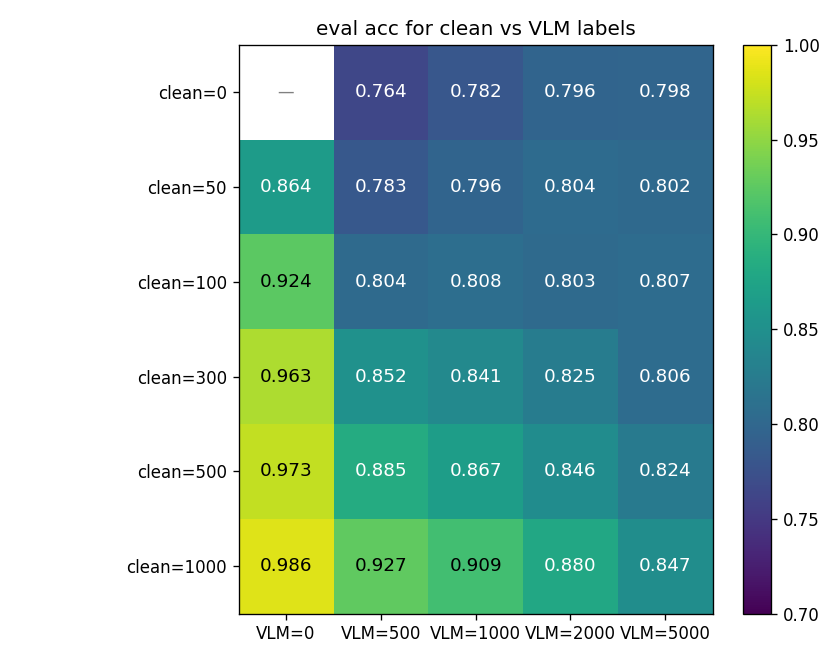

### Visualize learned margins

The learned failure margin `l(x)` for the clean x VLM labels combinations.

In [ ]:
show=[("ground truth",None),("clean 1000",(1000,0)),("vlm 1000",(0,1000)),("vlm 5000",(0,5000)),("100 clean + 1000 vlm",(100,1000))]
fig,ax=plt.subplots(1,len(show),figsize=(3.0*len(show),3.4)); ext=[-1.5,1.5,-1.5,1.5]
def ov(a):
    a.add_patch(plt.Circle((0,0),R,fill=False,color="k",lw=1.2))
    a.axhline(SW,color="k",ls="--",lw=.8); a.axhline(-SW,color="k",ls="--",lw=.8)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
for a,(name,cfg_) in zip(ax,show):
    F = GT if cfg_ is None else grid_margin(MODELS[cfg_] if cfg_ in MODELS else train_margin(*build(*cfg_,0),seed=0))
    v=max(abs(F).max(),1e-3)
    a.imshow(F.T,extent=ext,origin="lower",cmap="seismic",vmin=-v,vmax=v,interpolation="none")
    a.contour(xs,xs,F.T,levels=[0],colors="k",linewidths=1.1); a.set_title(name); ov(a)
plt.suptitle("Learned failure margin l(x) over the map (raw BT output)"); plt.tight_layout(); plt.show()

**Learned failure margin `l(x)`**, one grid per clean × VLM budget (from the full 5000-label run). Red = unsafe (low), blue = safe (high); the shape/ordering is what the margin provides. More clean labels sharpen the safe-set boundary; VLM-only stays coarser.

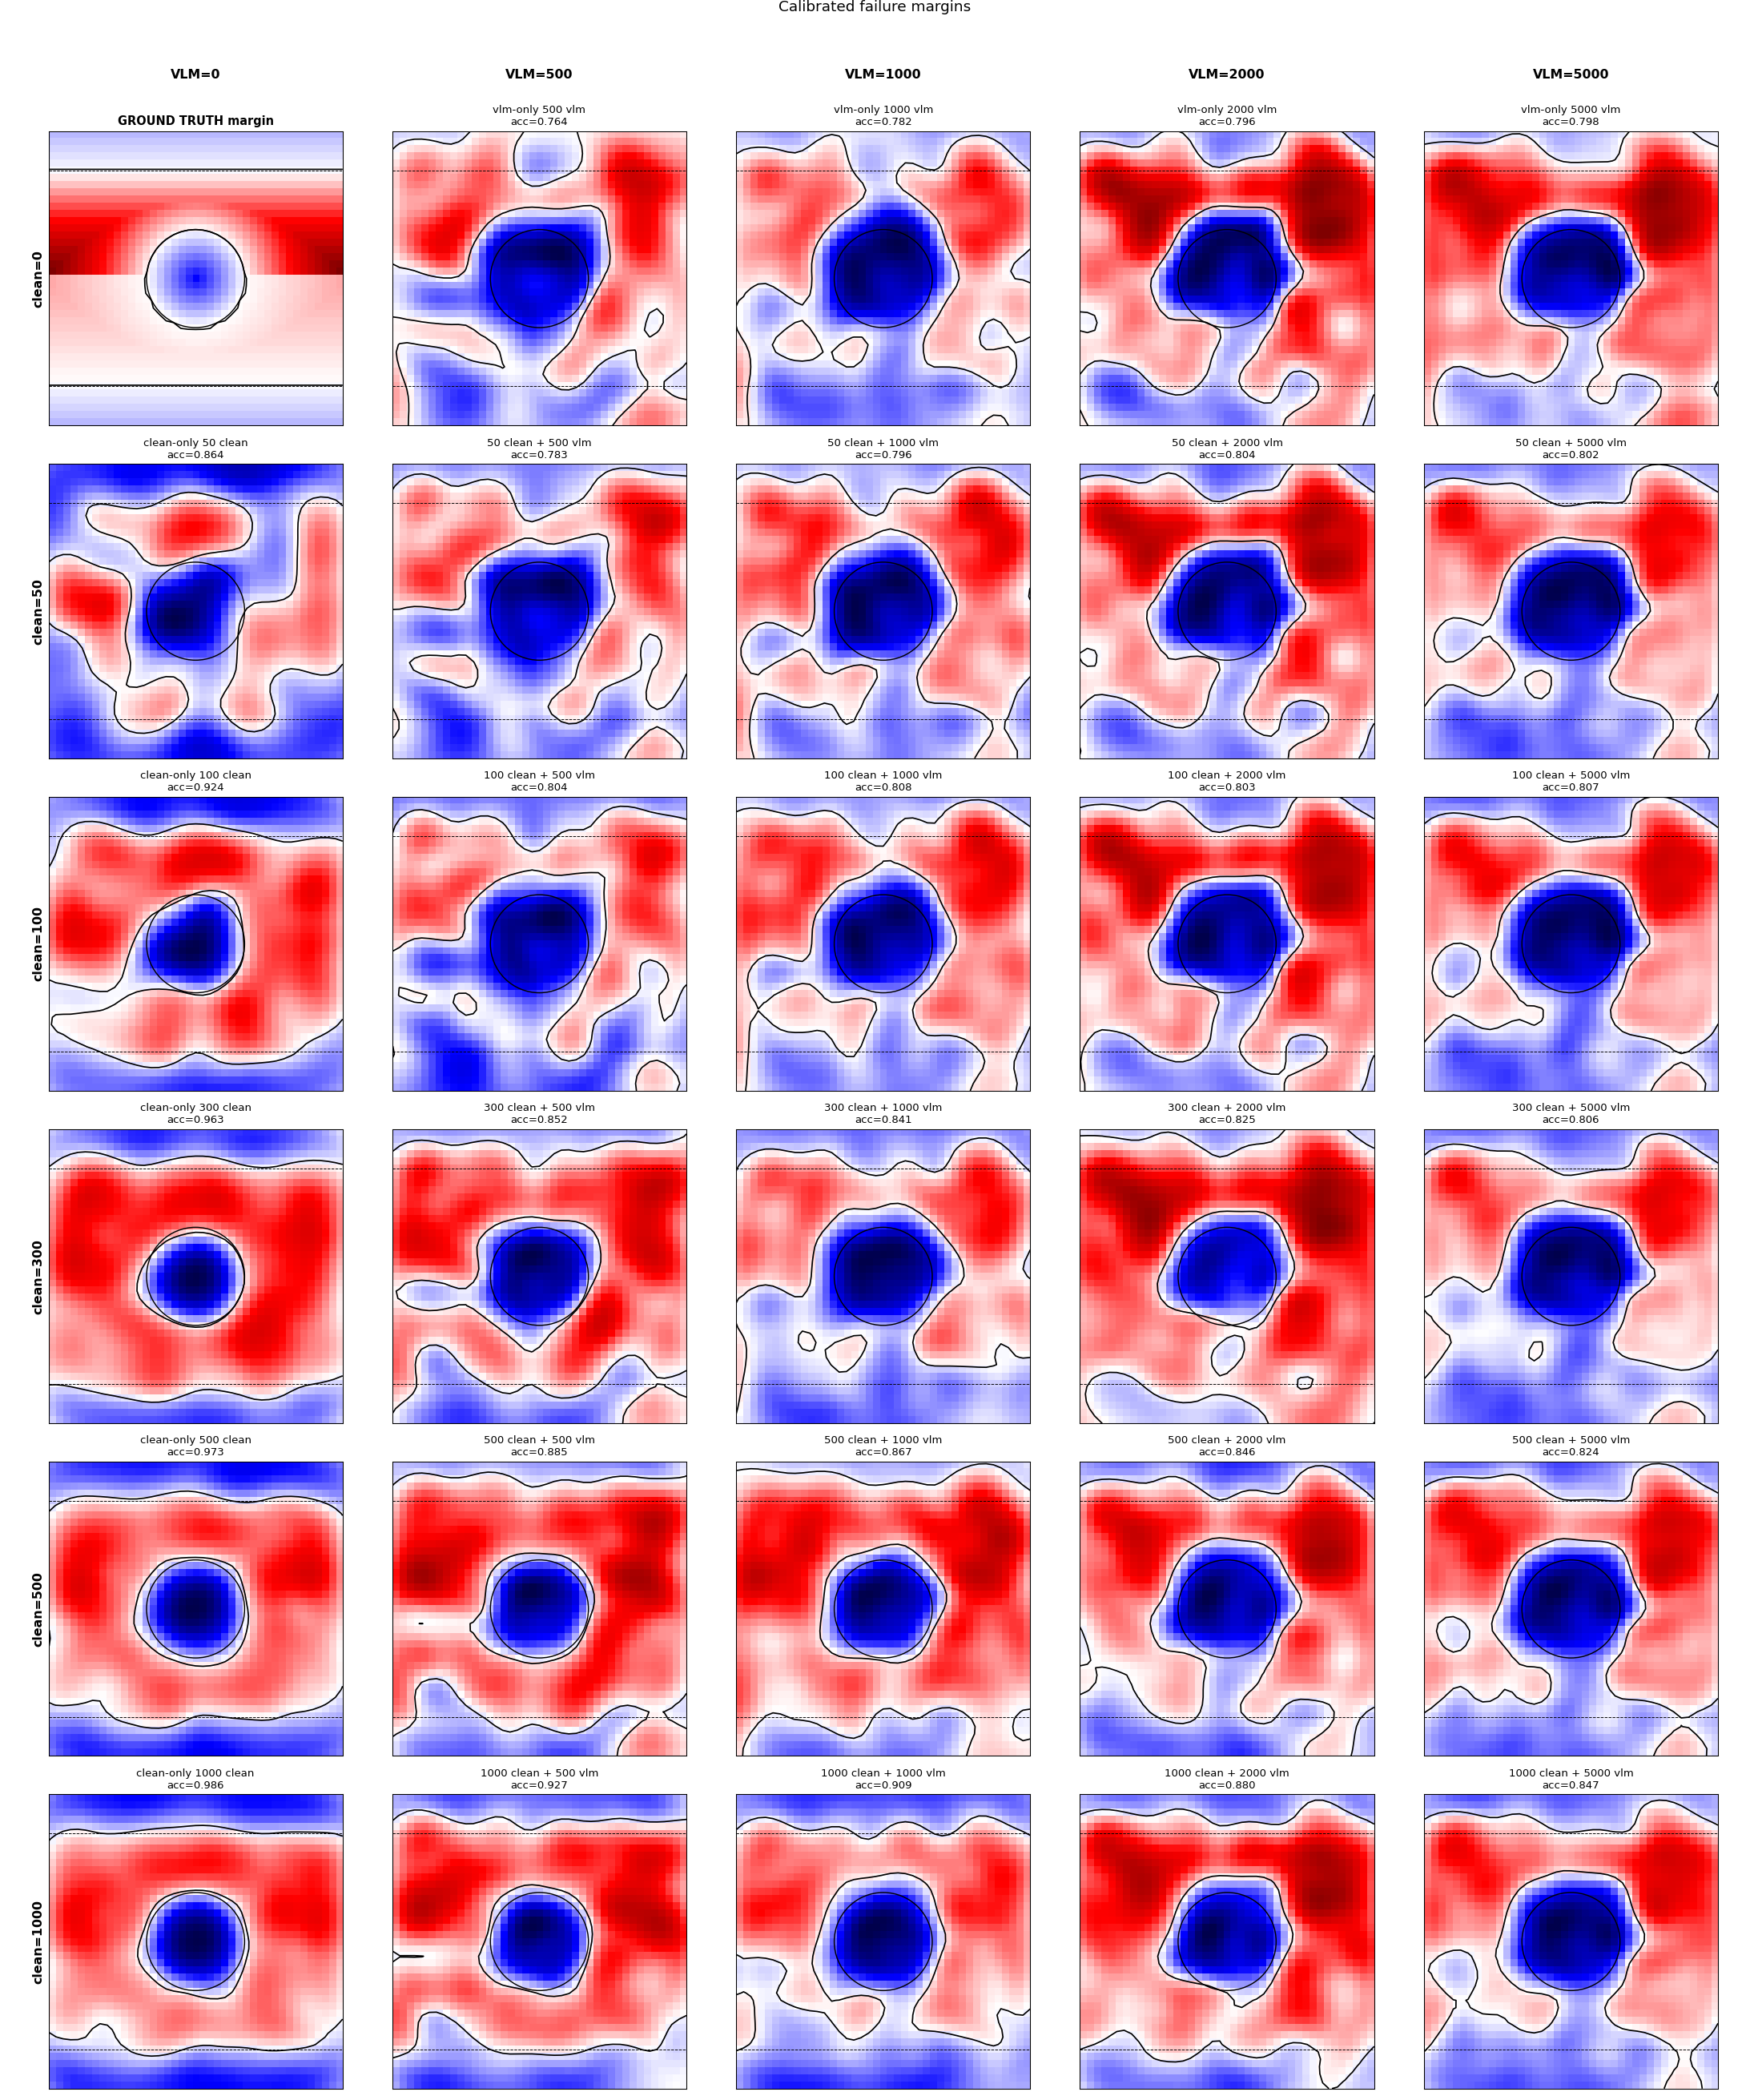